# Análise de Cancelamento de Clientes (Churn)

**Case:** uma empresa com mais de 800 mil clientes percebeu que a maior parte
da sua base é composta por clientes inativos (que já cancelaram o serviço).
O objetivo deste projeto é identificar os principais fatores associados ao
cancelamento e quantificar o peso de cada um, para orientar ações de retenção.

**Fonte dos dados:** dataset de clientes com informações demográficas, de uso
e de relacionamento com a empresa (50.000 registros, 12 colunas).

**Estrutura da análise:**
1. Carregamento e diagnóstico da base
2. Limpeza de dados (nulos, duplicatas, colunas irrelevantes)
3. Análise exploratória geral
4. Identificação de segmentos de risco
5. Modelagem preditiva (regressão logística) para quantificar o peso de cada fator
6. Conclusões e recomendações de negócio


## 1. Carregamento da base de dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

CAMINHO_DADOS = "../dados/cancelamentos.csv"

try:
    tabela = pd.read_csv(CAMINHO_DADOS)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Arquivo não encontrado em '{CAMINHO_DADOS}'. "
        "Verifique se o CSV está na pasta 'dados/' na raiz do projeto."
    )

print(f"Base carregada: {tabela.shape[0]} linhas, {tabela.shape[1]} colunas")
tabela.head()

Base carregada: 50000 linhas, 12 colunas


,CustomerID,idade,sexo,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,assinatura,duracao_contrato,total_gasto,meses_ultima_interacao,cancelou
0,349936.0,23.0,Male,13.0,22.0,2.0,1.0,Standard,Annual,909.58,23.0,0.0
1,100634.0,49.0,Male,55.0,16.0,3.0,6.0,Premium,Monthly,207.00,29.0,1.0
2,301263.0,30.0,Male,7.0,1.0,0.0,8.0,Basic,Annual,768.78,7.0,0.0
3,119358.0,26.0,Male,40.0,5.0,3.0,8.0,Premium,Annual,398.00,12.0,1.0
4,130955.0,27.0,Female,17.0,30.0,5.0,6.0,Basic,Annual,507.00,15.0,1.0


## 2. Diagnóstico e limpeza da base

Antes de qualquer análise, é preciso entender a qualidade dos dados: colunas
irrelevantes, valores nulos e — um ponto que costuma passar despercebido —
**linhas duplicadas**, que distorcem qualquer estatística calculada depois.

In [2]:
# CustomerID é um identificador único, não carrega informação analítica
tabela = tabela.drop(columns="CustomerID")

print("Tipos de dados e contagem de não-nulos:")
tabela.info()

Tipos de dados e contagem de não-nulos:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idade                   50000 non-null  float64
 1   sexo                    49997 non-null  str    
 2   tempo_como_cliente      49998 non-null  float64
 3   frequencia_uso          50000 non-null  float64
 4   ligacoes_callcenter     50000 non-null  float64
 5   dias_atraso             50000 non-null  float64
 6   assinatura              50000 non-null  str    
 7   duracao_contrato        50000 non-null  str    
 8   total_gasto             50000 non-null  float64
 9   meses_ultima_interacao  50000 non-null  float64
 10  cancelou                50000 non-null  float64
dtypes: float64(8), str(3)
memory usage: 4.2 MB


In [3]:
# Diagnóstico de nulos por coluna
nulos = tabela.isna().sum()
nulos = nulos[nulos > 0]
print("Colunas com valores nulos:")
print(nulos if not nulos.empty else "Nenhuma coluna com valores nulos.")
print(f"\nLinhas com pelo menos um valor nulo: {tabela.isna().any(axis=1).sum()} "
      f"({tabela.isna().any(axis=1).sum() / len(tabela):.3%} da base)")

Colunas com valores nulos:
sexo                  3
tempo_como_cliente    2
dtype: int64

Linhas com pelo menos um valor nulo: 4 (0.008% da base)


In [4]:
# Diagnóstico de duplicatas -- etapa que não pode ser pulada
duplicatas = tabela.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicatas} "
      f"({duplicatas / len(tabela):.2%} da base)")

Linhas duplicadas encontradas: 1469 (2.94% da base)


In [5]:
# Removendo duplicatas e nulos
linhas_antes = len(tabela)
tabela = tabela.drop_duplicates()
tabela = tabela.dropna()
linhas_depois = len(tabela)

print(f"Linhas removidas na limpeza: {linhas_antes - linhas_depois}")
print(f"Base final: {linhas_depois} linhas ({(linhas_depois/linhas_antes):.1%} da base original mantida)")

Linhas removidas na limpeza: 1473
Base final: 48527 linhas (97.1% da base original mantida)


## 3. Análise exploratória geral

Primeiro, a proporção geral de cancelamento na base já limpa.

In [6]:
taxa_geral = tabela["cancelou"].value_counts(normalize=True)
print("Distribuição geral de cancelamento:")
print(taxa_geral.map("{:.1%}".format))

Distribuição geral de cancelamento:
cancelou
1.0    56.7%
0.0    43.3%
Name: proportion, dtype: str


### Distribuição de cada variável em relação ao cancelamento

Geramos um grid com a distribuição de cada coluna, segmentada por
`cancelou`, para identificar visualmente quais variáveis parecem ter maior
relação com o cancelamento. Optamos por gráficos estáticos (Matplotlib/
Seaborn) em vez de interativos aqui: o Plotly, por padrão, envia todos os
valores brutos de cada coluna para o navegador fazer o binning no cliente —
isso deixaria o arquivo do notebook com dezenas de MB para pouco ganho real
de interatividade numa exploração inicial, e não renderiza no preview padrão
do GitHub de qualquer forma. Por isso, todo o projeto usa Matplotlib/Seaborn:
mantém o notebook leve e os gráficos visíveis diretamente no GitHub, sem
depender de renderização de JavaScript.

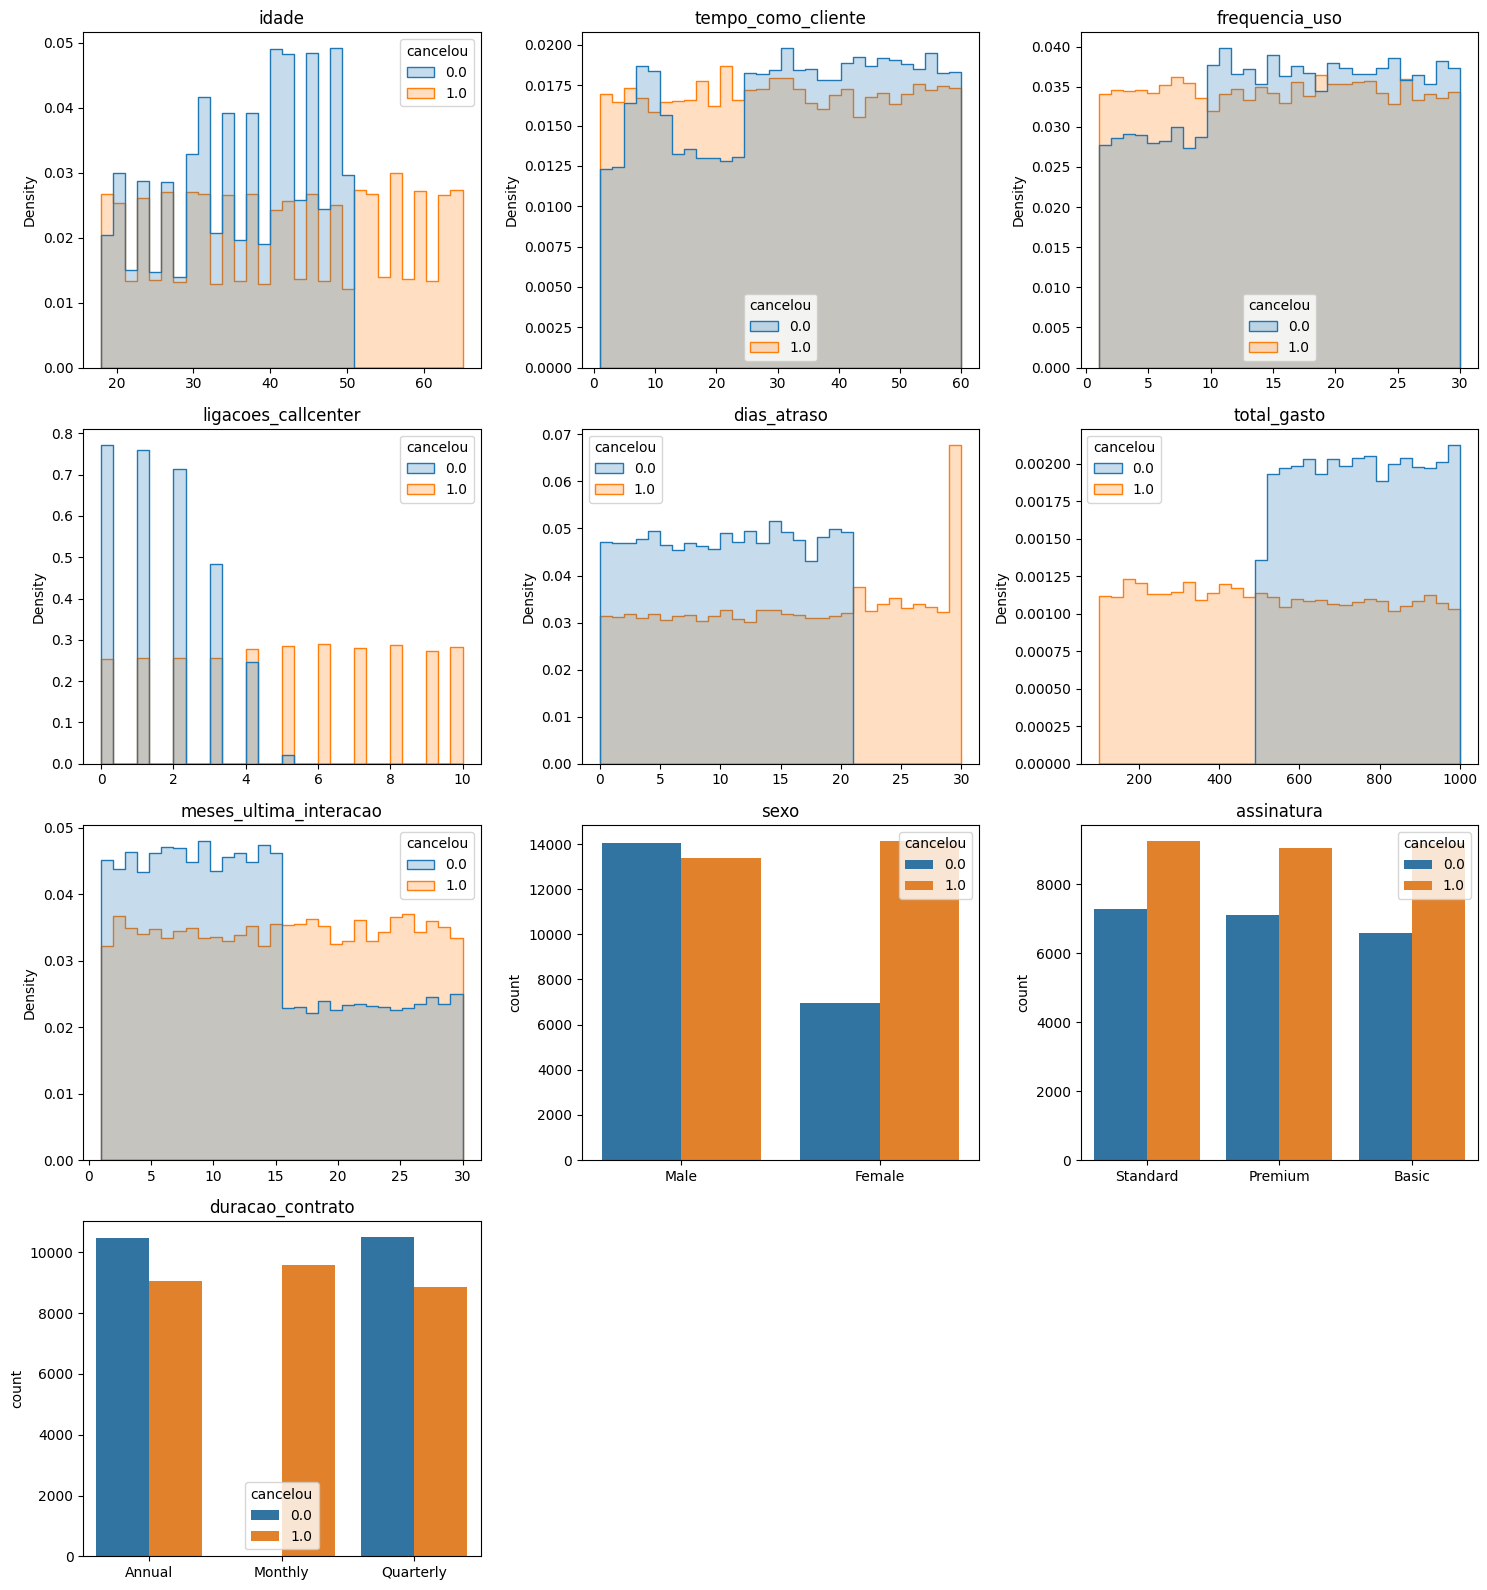

In [7]:
colunas_numericas = tabela.select_dtypes(include="number").columns.drop("cancelou")
colunas_categoricas = tabela.select_dtypes(exclude="number").columns

todas_colunas = list(colunas_numericas) + list(colunas_categoricas)
n_cols = 3
n_linhas = -(-len(todas_colunas) // n_cols)  # arredonda pra cima

fig, eixos = plt.subplots(n_linhas, n_cols, figsize=(15, 4 * n_linhas))
eixos = eixos.flatten()

for ax, coluna in zip(eixos, todas_colunas):
    if coluna in colunas_categoricas:
        sns.countplot(data=tabela, x=coluna, hue="cancelou", ax=ax)
    else:
        sns.histplot(data=tabela, x=coluna, hue="cancelou", bins=30,
                      element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(coluna)
    ax.set_xlabel("")

for ax in eixos[len(todas_colunas):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../imagens/distribuicao_variaveis.png", dpi=130)
plt.show()

## 4. Segmentos de risco

Na exploração acima, quatro variáveis se destacam por concentrar cancelamento
quase total em determinadas faixas. **Importante:** isso são *sinais de
alerta* — segmentos onde o cancelamento é praticamente certo — e não uma
"solução" de redução de churn. Filtrar essas linhas para fora da base não
reduz o cancelamento real; apenas remove da análise os clientes que já
cancelaram por esses motivos. O valor está em usar esses sinais para
**priorizar ações de retenção**, não em recalcular a taxa sobre uma base
artificialmente filtrada.

In [8]:
segmentos = {
    "Idade > 50 anos": tabela["idade"] > 50,
    "Mais de 4 ligações ao call center": tabela["ligacoes_callcenter"] > 4,
    "Mais de 20 dias de atraso no pagamento": tabela["dias_atraso"] > 20,
    "Plano mensal (Monthly)": tabela["duracao_contrato"] == "Monthly",
}

resumo_segmentos = []
for nome, condicao in segmentos.items():
    taxa = tabela.loc[condicao, "cancelou"].mean()
    n = condicao.sum()
    resumo_segmentos.append({"segmento": nome, "clientes": n, "taxa_cancelamento": taxa})

df_segmentos = pd.DataFrame(resumo_segmentos).sort_values("taxa_cancelamento", ascending=False)
df_segmentos["taxa_cancelamento"] = df_segmentos["taxa_cancelamento"].map("{:.1%}".format)
df_segmentos

,segmento,clientes,taxa_cancelamento
0,Idade > 50 anos,8886,100.0%
2,Mais de 20 dias de atraso no pagamento,9356,100.0%
3,Plano mensal (Monthly),9595,100.0%
1,Mais de 4 ligações ao call center,15764,99.0%


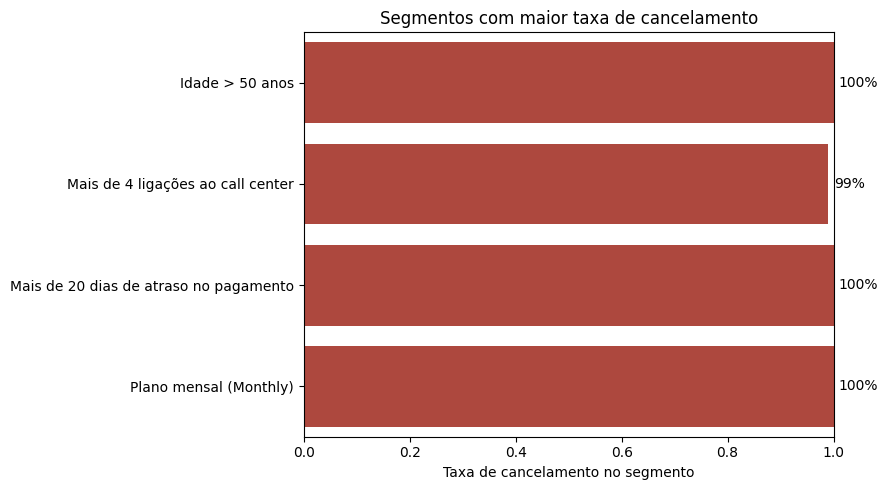

In [9]:
# Versão estática (matplotlib) para exportar como imagem no README
resumo_plot = pd.DataFrame(resumo_segmentos)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=resumo_plot, y="segmento", x="taxa_cancelamento", ax=ax, color="#c0392b")
ax.set_xlim(0, 1)
ax.set_xlabel("Taxa de cancelamento no segmento")
ax.set_ylabel("")
ax.set_title("Segmentos com maior taxa de cancelamento")
for i, v in enumerate(resumo_plot["taxa_cancelamento"]):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.savefig("../imagens/segmentos_risco.png", dpi=150)
plt.show()

## 5. Modelagem preditiva: quantificando o peso de cada fator

A análise de segmentos mostra *que* esses fatores importam, mas não *o
quanto* cada um pesa em relação aos outros, controlando pelas demais
variáveis. Para isso, treinamos uma regressão logística com `cancelou` como
variável-alvo.

In [10]:
df_modelo = tabela.copy()
df_modelo["sexo"] = df_modelo["sexo"].map({"Male": 0, "Female": 1})
df_modelo = pd.get_dummies(df_modelo, columns=["assinatura", "duracao_contrato"], drop_first=True)

X = df_modelo.drop(columns="cancelou")
y = df_modelo["cancelou"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

escalador = StandardScaler()
X_treino_esc = escalador.fit_transform(X_treino)
X_teste_esc = escalador.transform(X_teste)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino_esc, y_treino)

y_pred = modelo.predict(X_teste_esc)

print(f"Acurácia: {accuracy_score(y_teste, y_pred):.1%}")
print(f"Precisão: {precision_score(y_teste, y_pred):.1%}")
print(f"Recall:   {recall_score(y_teste, y_pred):.1%}")
print()
print(classification_report(y_teste, y_pred, target_names=["Não cancelou", "Cancelou"]))

Acurácia: 89.3%
Precisão: 92.4%
Recall:   88.5%

              precision    recall  f1-score   support

Não cancelou       0.86      0.90      0.88      5247
    Cancelou       0.92      0.88      0.90      6885

    accuracy                           0.89     12132
   macro avg       0.89      0.89      0.89     12132
weighted avg       0.89      0.89      0.89     12132



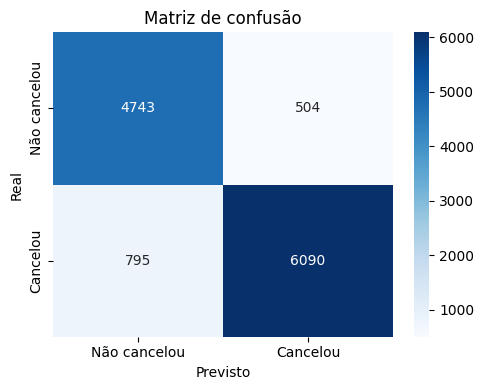

In [11]:
# Matriz de confusão
matriz = confusion_matrix(y_teste, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não cancelou", "Cancelou"],
            yticklabels=["Não cancelou", "Cancelou"], ax=ax)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusão")
plt.tight_layout()
plt.savefig("../imagens/matriz_confusao.png", dpi=150)
plt.show()

/tmp/ipykernel_568/291989081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes.values, y=coeficientes.index, palette=cores, ax=ax)


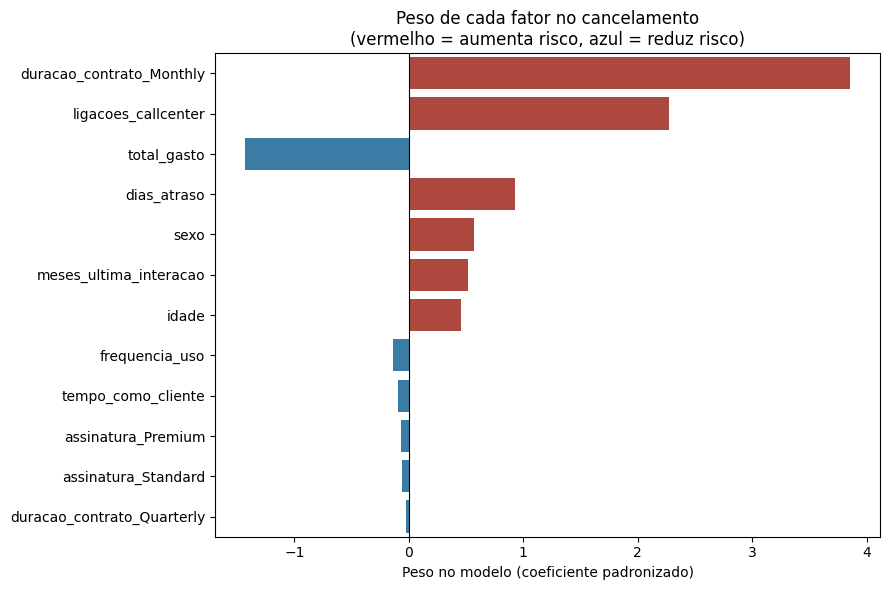

duracao_contrato_Monthly      3.853834
ligacoes_callcenter           2.273407
total_gasto                  -1.427867
dias_atraso                   0.931159
sexo                          0.574480
meses_ultima_interacao        0.516485
idade                         0.458396
frequencia_uso               -0.141714
tempo_como_cliente           -0.096338
assinatura_Premium           -0.066459
assinatura_Standard          -0.059771
duracao_contrato_Quarterly   -0.019974
dtype: float64

In [12]:
# Peso de cada variável no modelo (coeficientes padronizados)
coeficientes = pd.Series(modelo.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cores = ["#c0392b" if v > 0 else "#2980b9" for v in coeficientes.values]
sns.barplot(x=coeficientes.values, y=coeficientes.index, palette=cores, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Peso no modelo (coeficiente padronizado)")
ax.set_ylabel("")
ax.set_title("Peso de cada fator no cancelamento\n(vermelho = aumenta risco, azul = reduz risco)")
plt.tight_layout()
plt.savefig("../imagens/peso_fatores.png", dpi=150)
plt.show()

coeficientes

## 6. Conclusões e recomendações de negócio

**Fatores que mais aumentam o risco de cancelamento** (por ordem de peso no
modelo):

1. **Plano mensal (`duracao_contrato = Monthly`)** — o fator de maior peso.
   Clientes sem contrato de longo prazo têm risco muito maior de sair.
2. **Ligações ao call center** — cada ligação adicional aumenta o risco;
   acima de 4 ligações, o cancelamento é praticamente certo.
3. **Dias de atraso no pagamento** — atraso persistente é um forte preditor.
4. **Idade** e **tempo desde a última interação** também pesam, mas menos.

**Fator que reduz o risco:**
- **Total gasto** — clientes com maior gasto acumulado tendem a permanecer,
  o que é consistente com maior engajamento/investimento no serviço.

**Recomendações:**
- Oferecer incentivos para migração de planos mensais para anuais/trimestrais
  (ex: desconto progressivo).
- Criar um fluxo de atendimento prioritário para clientes que já fizeram 3+
  ligações ao call center, antes que cheguem à 4ª.
- Acionar a equipe financeira para negociação proativa a partir de ~15 dias
  de atraso, antes de atingir a faixa crítica de 20+ dias.
- Usar o modelo como *score de risco* contínuo (não como filtro) para
  priorizar campanhas de retenção nos clientes com maior probabilidade
  prevista de cancelamento.

O modelo atingiu **89% de acurácia** no conjunto de teste, com boa precisão e
recall para a classe "cancelou" — validando estatisticamente os padrões
identificados na análise exploratória.
